# Inverter Nonlinearity Compensation NN

목표 식은 다음과 같습니다.

\[
\hat V_{dsr,\mathrm{nl}}(x)
= \frac{2}{3}\left[NN(x)+NN\left(\frac{x}{2}\right)\right]
\]

여기서 `NN(x)`와 `NN(x/2)`는 **서로 다른 신경망이 아니라 동일한 신경망을 두 번 호출**합니다. 따라서 두 계산 경로가 같은 파라미터를 공유하며, 하나의 최종 loss에 대해 `backward()`를 한 번 수행하면 두 경로의 gradient가 자동으로 합산됩니다.

학습 타깃은 제공된 데이터의

\[
V_{dsr}^{*}-I R
\]

입니다.

In [ ]:
# 1. 라이브러리 및 재현성 설정

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from google.colab import drive

# GitHub repository를 저장할 위치
REPO_ROOT = "/content/InverterNonlinearity_Compensation_copy"
# 저장소가 없으면 clone
if not os.path.exists(REPO_ROOT):
    !git clone -q https://github.com/Jaehoon-Shim/MTPA_example.git {REPO_ROOT}
os.makedirs('/content/InverterNonlinearity_Compensation_copy/data', exist_ok=True)
os.makedirs('/content/InverterNonlinearity_Compensation_copy/results', exist_ok=True)


drive.mount('/content/drive')
os.makedirs('/content/drive/MyDrive/Colab Notebooks/InverterNonlinearity_Compensation/data', exist_ok=True)
os.makedirs('/content/drive/MyDrive/Colab Notebooks/InverterNonlinearity_Compensation/results', exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch version:', torch.__version__)
print('Device:', DEVICE)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PyTorch version: 2.11.0+cpu
Device: cpu


In [ ]:
# 2. 설정값

HID_NUM = 12
INITIAL_LR = 0.01
WEIGHT_DECAY = 2e-4
DECAY_RATE = 0.999
NUM_EPOCHS = 1000
BATCH_SIZE = 8
PRINT_INTERVAL = 100
TEST_DATA_RATIO = 0.25
N_ZERO = 3

# x는 최대 전류로 PU 정규화합니다.
# PU 정규화는 x/2 관계를 그대로 보존합니다:
# (x/2)/I_base = (x/I_base)/2
I_BASE = 4.6

RESULTS_DIR = '/content/InverterNonlinearity_Compensation_copy/results/'
os.makedirs(RESULTS_DIR, exist_ok=True)

MODEL_PATH = os.path.join(RESULTS_DIR, 'model.pt')
CHECKPOINT_PATH = os.path.join(RESULTS_DIR, 'model_checkpoint.pt')
LOSS_FIG_PATH = os.path.join(RESULTS_DIR, 'training_loss.png')
PRED_FIG_PATH = os.path.join(RESULTS_DIR, 'prediction.png')
PRED_CSV_PATH = os.path.join(RESULTS_DIR, 'prediction.csv')


In [25]:
# 3. 제공된 데이터 입력

current = np.array([
    0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4,
    1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0,
    3.2, 3.4, 3.6, 3.8, 4.0, 4.2, 4.4, 4.6
], dtype=np.float32)

v_dsr_ref = np.array([
    0.0, 0.888037384, 1.062867641, 1.210893750,
    1.345420480, 1.468046069, 1.554850101, 1.606069446,
    1.643472314, 1.675461411, 1.705542564, 1.731593013,
    1.756597757, 1.778788567, 1.801182151, 1.824661493,
    1.846482277, 1.867971897, 1.887866497, 1.907626390,
    1.927348614, 1.945739985, 1.962411404, 1.982692480
], dtype=np.float32)

v_target = np.array([
    0.0, 0.883157384, 1.053107641, 1.196253750,
    1.325900480, 1.443646069, 1.525570101, 1.571909446,
    1.604432314, 1.631541411, 1.656742564, 1.677913013,
    1.698037757, 1.715348567, 1.732862151, 1.751461493,
    1.768402277, 1.785011897, 1.800026497, 1.814906390,
    1.829748614, 1.843259985, 1.855051404, 1.870452480
], dtype=np.float32)

data = pd.DataFrame({
    'Idsr_A': current,
    'Vdsr_ref_V': v_dsr_ref,
    'Vdsr_ref_minus_IR_V': v_target,
})

display(data)


,Idsr_A,Vdsr_ref_V,Vdsr_ref_minus_IR_V
0,0.0,0.000000,0.000000
1,0.2,0.888037,0.883157
2,0.4,1.062868,1.053108
3,0.6,1.210894,1.196254
4,0.8,1.345420,1.325900
5,1.0,1.468046,1.443646
6,1.2,1.554850,1.525570
7,1.4,1.606069,1.571909
8,1.6,1.643472,1.604432
9,1.8,1.675461,1.631541


## 정규화 방식

입력만 다음과 같이 PU 정규화합니다.

\[
x_{pu}=\frac{x}{I_{base}}
\]

출력은 전압 단위[V] 그대로 학습합니다. 따라서 합성 출력

\[
\frac{2}{3}\left[NN(x)+NN(x/2)\right]
\]

의 물리적 의미가 그대로 유지됩니다. `MINMAX` 출력 정규화를 사용할 경우 offset 때문에 두 NN 출력의 합과 역정규화 순서에 주의해야 하므로 여기서는 사용하지 않습니다.

In [26]:
# 4. Train/Test 분할
# 데이터가 매우 적으므로 내부 전류 범위에서 일정 간격의 점을 test로 선택합니다.
# 양 끝점(0 A, 최대 전류)은 곡선 경계 평가를 위해 train/test 양쪽에 모두 포함합니다.

all_indices = np.arange(len(data))
endpoint_indices = np.array([0, len(data) - 1], dtype=int)

# 내부 test 점 + 양 끝점
interior_test_indices = np.array([2, 6, 10, 14, 18, 22], dtype=int)
interior_test_indices = interior_test_indices[
    (interior_test_indices > 0) & (interior_test_indices < len(data) - 1)
]
test_indices = np.unique(
    np.concatenate([endpoint_indices, interior_test_indices])
)

# 내부 test 점은 학습에서 제외하되, 양 끝점은 학습에도 중복 포함
train_indices = np.setdiff1d(all_indices, interior_test_indices)
train_indices = np.unique(
    np.concatenate([train_indices, endpoint_indices])
)

x_all = current.reshape(-1, 1)
y_all = v_target.reshape(-1, 1)

x_train = x_all[train_indices]
y_train = y_all[train_indices]

# (0, 0) N_ZERO개 추가
x_zero = np.zeros((N_ZERO, 1), dtype=np.float32)
y_zero = np.zeros((N_ZERO, 1), dtype=np.float32)
x_train = np.concatenate([x_train, x_zero], axis=0)
y_train = np.concatenate([y_train, y_zero], axis=0)

x_test = x_all[test_indices]
y_test = y_all[test_indices]

# 입력 PU 정규화
x_train_pu = x_train / I_BASE
x_test_pu = x_test / I_BASE
x_all_pu = x_all / I_BASE

x_train_t = torch.tensor(x_train_pu, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
x_test_t = torch.tensor(x_test_pu, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)
x_all_t = torch.tensor(x_all_pu, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(x_train_t, y_train_t),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_loader = DataLoader(
    TensorDataset(x_test_t, y_test_t),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print('Endpoint indices:', endpoint_indices)
print('Train indices   :', train_indices)
print('Test indices    :', test_indices)
print('Train samples   :', len(train_indices))
print('Test samples    :', len(test_indices))
print('Last point in train:', (len(data) - 1) in train_indices)
print('Last point in test :', (len(data) - 1) in test_indices)

print(x_train)
print(y_train)

Endpoint indices: [ 0 23]
Train indices   : [ 0  1  3  4  5  7  8  9 11 12 13 15 16 17 19 20 21 23]
Test indices    : [ 0  2  6 10 14 18 22 23]
Train samples   : 18
Test samples    : 8
Last point in train: True
Last point in test : True
[[0. ]
 [0.2]
 [0.6]
 [0.8]
 [1. ]
 [1.4]
 [1.6]
 [1.8]
 [2.2]
 [2.4]
 [2.6]
 [3. ]
 [3.2]
 [3.4]
 [3.8]
 [4. ]
 [4.2]
 [4.6]
 [0. ]
 [0. ]
 [0. ]]
[[0.       ]
 [0.8831574]
 [1.1962538]
 [1.3259004]
 [1.4436461]
 [1.5719094]
 [1.6044323]
 [1.6315414]
 [1.6779131]
 [1.6980377]
 [1.7153486]
 [1.7514615]
 [1.7684022]
 [1.7850119]
 [1.8149064]
 [1.8297486]
 [1.8432599]
 [1.8704525]
 [0.       ]
 [0.       ]
 [0.       ]]


## 공유 신경망과 합성 모델

`base_nn`은 한 개뿐입니다. `CompositeCompensator.forward()` 안에서 동일한 `base_nn`을 두 번 호출합니다.

```python
y_x = self.base_nn(x)
y_half = self.base_nn(x / 2)
y_combined = (2/3) * (y_x + y_half)
```

PyTorch autograd가 두 경로를 모두 추적하므로, `loss.backward()` 한 번으로 두 경로의 gradient가 동일한 파라미터에 누적됩니다.

In [27]:
# 5. 모델 정의
class BaseNN(nn.Module):
    """한 개의 공유 신경망 NN(.)"""

    def __init__(self, hid_num):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hid_num),
            nn.ReLU(),
            nn.Linear(hid_num, hid_num),
            nn.ReLU(),
            nn.Linear(hid_num, 1),
        )
    def forward(self, x):
        return self.net(x)

class Compensator(nn.Module):
    """
    y_hat(x) = 2/3 * [NN(x) + NN(x/2)]

    x는 PU 정규화된 전류입니다.

    """

    def __init__(self, hid_num=20):
        super().__init__()
        self.base_nn = BaseNN(hid_num=hid_num)

    def forward(self, x, return_components=False):
        y_x = self.base_nn(x)
        y_half = self.base_nn(x / 2.0)
        y_combined = (2.0 / 3.0) * (y_x + y_half)

        if return_components:
            return y_combined, y_x, y_half
        return y_combined


model = Compensator(hid_num=HID_NUM).to(DEVICE)
criterion = nn.MSELoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=INITIAL_LR,
    weight_decay=WEIGHT_DECAY,
)

print(model)
print('Trainable parameter count:', sum(p.numel() for p in model.parameters() if p.requires_grad))


Compensator(
  (base_nn): BaseNN(
    (net): Sequential(
      (0): Linear(in_features=1, out_features=12, bias=True)
      (1): ReLU()
      (2): Linear(in_features=12, out_features=12, bias=True)
      (3): ReLU()
      (4): Linear(in_features=12, out_features=1, bias=True)
    )
  )
)
Trainable parameter count: 193


In [28]:
# 6. 모델 학습
# 최종 합성 출력에 대해 loss를 한 번 계산하고 backward()도 한 번만 수행합니다.

train_losses = []
test_losses = []
lr_history = []

for epoch in range(NUM_EPOCHS):
    lr = INITIAL_LR * (DECAY_RATE ** epoch)
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr
    lr_history.append(lr)

    model.train()
    train_loss_sum = 0.0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(DEVICE)
        batch_y = batch_y.to(DEVICE)

        optimizer.zero_grad()

        # 내부에서 동일 NN을 x와 x/2에 대해 두 번 계산
        combined_pred = model(batch_x)

        # 최종 조합 결과 하나에 대해 loss 계산
        loss = criterion(combined_pred, batch_y)

        # backward는 한 번. 두 경로의 gradient가 공유 파라미터에 합산됨
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * batch_x.size(0)

    train_loss = train_loss_sum / len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    test_loss_sum = 0.0
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(DEVICE)
            batch_y = batch_y.to(DEVICE)
            combined_pred = model(batch_x)
            test_loss_sum += criterion(combined_pred, batch_y).item() * batch_x.size(0)

    test_loss = test_loss_sum / len(test_loader.dataset)
    test_losses.append(test_loss)

    if (epoch + 1) % PRINT_INTERVAL == 0 or epoch == 0:
        print(
            f'Epoch [{epoch + 1:4d}/{NUM_EPOCHS}], '
            f'Train MSE: {train_loss:.8f}, '
            f'Test MSE: {test_loss:.8f}, '
            f'LR: {lr:.8f}'
        )


Epoch [   1/1000], Train MSE: 1.42924312, Test MSE: 1.29542303, LR: 0.01000000
Epoch [ 100/1000], Train MSE: 0.00919363, Test MSE: 0.00323844, LR: 0.00905698
Epoch [ 200/1000], Train MSE: 0.00109397, Test MSE: 0.00060699, LR: 0.00819468
Epoch [ 300/1000], Train MSE: 0.00082909, Test MSE: 0.00102925, LR: 0.00741448
Epoch [ 400/1000], Train MSE: 0.00087060, Test MSE: 0.00123705, LR: 0.00670857
Epoch [ 500/1000], Train MSE: 0.00074499, Test MSE: 0.00121787, LR: 0.00606986
Epoch [ 600/1000], Train MSE: 0.00097466, Test MSE: 0.00136127, LR: 0.00549196
Epoch [ 700/1000], Train MSE: 0.00066845, Test MSE: 0.00145085, LR: 0.00496908
Epoch [ 800/1000], Train MSE: 0.00056583, Test MSE: 0.00129000, LR: 0.00449599
Epoch [ 900/1000], Train MSE: 0.00077347, Test MSE: 0.00149625, LR: 0.00406793
Epoch [1000/1000], Train MSE: 0.00054963, Test MSE: 0.00153128, LR: 0.00368063


In [29]:
# 7. 전체 데이터 예측 및 각 성분 확인

model.eval()
with torch.no_grad():
    combined_pred_t, nn_x_t, nn_half_t = model(
        x_all_t.to(DEVICE),
        return_components=True,
    )

combined_pred = combined_pred_t.cpu().numpy().reshape(-1)
nn_x = nn_x_t.cpu().numpy().reshape(-1)
nn_half = nn_half_t.cpu().numpy().reshape(-1)

prediction_df = pd.DataFrame({
    'Idsr_A': current,
    'target_Vdsr_star_minus_IR_V': v_target,
    'NN_x_V': nn_x,
    'NN_x_over_2_V': nn_half,
    'combined_2over3_sum_V': combined_pred,
    'error_V': combined_pred - v_target,
    'is_test': np.isin(all_indices, test_indices),
})

mse_all = np.mean((combined_pred - v_target) ** 2)
mae_all = np.mean(np.abs(combined_pred - v_target))
max_abs_error = np.max(np.abs(combined_pred - v_target))

print(f'All-data MSE       : {mse_all:.10f}')
print(f'All-data MAE       : {mae_all:.10f} V')
print(f'Max absolute error : {max_abs_error:.10f} V')
display(prediction_df)


All-data MSE       : 0.0011302721
All-data MAE       : 0.0259517878 V
Max absolute error : 0.0946511030 V


,Idsr_A,target_Vdsr_star_minus_IR_V,NN_x_V,NN_x_over_2_V,combined_2over3_sum_V,error_V,is_test
0,0.0,0.000000,0.002809,0.002809,0.003746,0.003746,True
1,0.2,0.883157,0.805505,0.413514,0.812679,-0.070478,False
2,0.4,1.053108,0.916133,0.805505,1.147759,0.094651,True
3,0.6,1.196254,1.022530,0.860819,1.255566,0.059312,False
4,0.8,1.325900,1.087581,0.916133,1.335809,0.009909,False
5,1.0,1.443646,1.152632,0.971446,1.416052,-0.027594,False
6,1.2,1.525570,1.216135,1.022530,1.492443,-0.033127,True
7,1.4,1.571909,1.260025,1.055055,1.543387,-0.028523,False
8,1.6,1.604432,1.271580,1.087581,1.572774,-0.031658,False
9,1.8,1.631541,1.283136,1.120107,1.602161,-0.029380,False


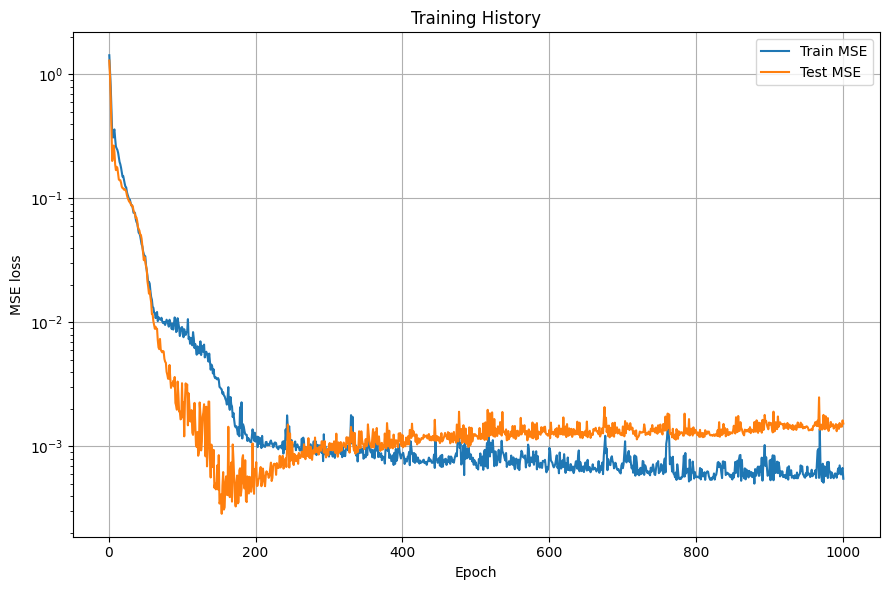

In [30]:
# 8. 학습 loss 그래프

plt.figure(figsize=(9, 6))
plt.semilogy(np.arange(1, NUM_EPOCHS + 1), train_losses, label='Train MSE')
plt.semilogy(np.arange(1, NUM_EPOCHS + 1), test_losses, label='Test MSE')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.title('Training History')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(LOSS_FIG_PATH, dpi=300, bbox_inches='tight')
plt.show()


Measured target count: 24
NN prediction count  : 24


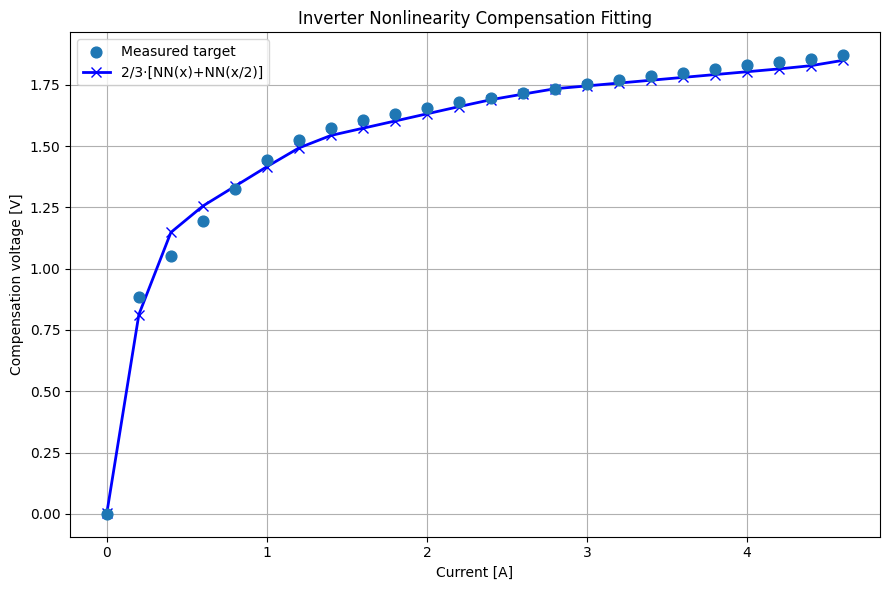

In [31]:

# 9. 실제값과 동일한 x 위치에서 2/3·[NN(x)+NN(x/2)] 비교
x_plot = current.astype(np.float32).reshape(-1, 1)
x_plot_t = torch.tensor(x_plot / I_BASE, dtype=torch.float32, device=DEVICE)
model.eval()
with torch.no_grad():
    nn_x_t = model.base_nn(x_plot_t)
    nn_x_half_t = model.base_nn(x_plot_t / 2.0)
    pred_t = (2.0 / 3.0) * (nn_x_t + nn_x_half_t)
pred = pred_t.cpu().numpy().reshape(-1)
print('Measured target count:', len(v_target))
print('NN prediction count  :', len(pred))
plt.figure(figsize=(9, 6))
plt.scatter(current, v_target, s=60, label='Measured target', zorder=4)
plt.plot(current, pred, marker='x', linewidth=2.0, markersize=7, label='2/3·[NN(x)+NN(x/2)]', zorder=3, color = 'blue')
plt.xlabel('Current [A]')
plt.ylabel('Compensation voltage [V]')
plt.title('Inverter Nonlinearity Compensation Fitting')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(PRED_FIG_PATH, dpi=300, bbox_inches='tight')
plt.show()

In [32]:
# 10. 모델 및 결과 저장
# 기본 모델 가중치는 RESULTS_DIR/model.pt로 저장

checkpoint = {
    'model_state_dict': model.state_dict(),
    'hid_num': HID_NUM,
    'i_base': I_BASE,
    'equation': 'y = (2/3) * (NN(x) + NN(x/2))',
    'input_normalization': 'x_pu = x_A / I_BASE',
    'output_unit': 'V',
    'seed': SEED,
}

torch.save(model.state_dict(), MODEL_PATH)
torch.save(checkpoint, CHECKPOINT_PATH)
prediction_df.to_csv(PRED_CSV_PATH, index=False)

print('Model saved       :', MODEL_PATH)
print('Checkpoint saved :', CHECKPOINT_PATH)
print('Prediction CSV   :', PRED_CSV_PATH)


Model saved       : /content/drive/MyDrive/Colab Notebooks/InverterNonlinearity_Compensation/results/model.pt
Checkpoint saved : /content/drive/MyDrive/Colab Notebooks/InverterNonlinearity_Compensation/results/model_checkpoint.pt
Prediction CSV   : /content/drive/MyDrive/Colab Notebooks/InverterNonlinearity_Compensation/results/prediction.csv


In [33]:
# 11. 저장 모델 재로딩 및 단일 전류 추론 예시

loaded_model = Compensator(hid_num=HID_NUM).to(DEVICE)
loaded_checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
loaded_model.load_state_dict(loaded_checkpoint['model_state_dict'])
loaded_model.eval()

x_ampere = 2.0
x_pu = torch.tensor([[x_ampere / I_BASE]], dtype=torch.float32, device=DEVICE)

with torch.no_grad():
    y_combined, y_x, y_half = loaded_model(x_pu, return_components=True)

print(f'x = {x_ampere:.3f} A')
print(f'NN(x)             = {y_x.item():.8f} V')
print(f'NN(x/2)           = {y_half.item():.8f} V')
print(f'2/3*(sum)         = {y_combined.item():.8f} V')


x = 2.000 A
NN(x)             = 1.29469109 V
NN(x/2)           = 1.15263224 V
2/3*(sum)         = 1.63154888 V


## 구현상 핵심

- `Compensator` 안에는 `BaseNN`이 **한 개만** 존재합니다.
- `NN(x)`와 `NN(x/2)`는 같은 weight와 bias를 사용합니다.
- 최종 출력 하나로 MSE를 계산합니다.
- `loss.backward()`는 한 번만 호출합니다.
- autograd가 두 계산 경로의 gradient를 합산하여 공유 NN 파라미터를 갱신합니다.

즉, 의도한 “신경망 계산은 두 번, 종합 출력에 대한 backpropagation은 한 번” 구조입니다.